In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error,mean_absolute_percentage_error,root_mean_squared_error,mean_squared_error,r2_score
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv(r"C:\Users\vidit\Downloads\watches_cleaned.csv")

In [3]:
df.head(10)

,price,brand,model,ref,yop,cond,sex,size
0,43500.0,Audemars Piguet,Royal Oak Offshore Chronograph,26237ST.OO.1000ST.01,2019.0,Unworn,Men's watch/Unisex,42.0
1,71500.0,Audemars Piguet,Royal Oak Selfwinding,15300ST.OO.1220ST.02,2012.0,Very good,Men's watch/Unisex,39.0
2,79191.0,Audemars Piguet,Royal Oak Chronograph,26331ST,2020.0,Unworn,Unknown,41.0
3,108000.0,Audemars Piguet,Royal Oak Chronograph,26715ST.OO.1356ST.01,2022.0,New,Men's watch/Unisex,38.0
4,27500.0,Audemars Piguet,Royal Oak Offshore Chronograph,26170ST.OO.1000ST.01,2020.0,Very good,Men's watch/Unisex,40.0
5,41000.0,Audemars Piguet,Royal Oak Offshore Diver,15710ST.OO.A051CA.01,2018.0,Unworn,Men's watch/Unisex,42.0
6,43500.0,Audemars Piguet,Royal Oak Offshore Diver Chronograph,26703ST.OO.A051CA.01,2016.0,Very good,Men's watch/Unisex,42.0
7,37800.0,Audemars Piguet,Royal Oak Offshore Chronograph,26470IO.OO.A006CA.01,2019.0,Very good,Men's watch/Unisex,42.0
8,32182.0,Audemars Piguet,Royal Oak Dual Time,26120ST.OO.1220ST.03,2015.0,Good,Men's watch/Unisex,39.0
9,36473.0,Audemars Piguet,Royal Oak Offshore Chronograph,26401.RO.OO.A002.CA.01,2016.0,Good,Men's watch/Unisex,44.0


In [4]:
df.tail(10)

,price,brand,model,ref,yop,cond,sex,size
284481,8895.0,Zenith,Chronomaster Sport,03.3100.3600/21.M3100,2023.0,Unworn,Unknown,40.0
284482,2995.0,Zenith,Elite,01.0125.680,2008.0,Very good,Men's watch/Unisex,37.0
284483,9950.0,Zenith,Defy,95.9100.9004/01.I001,2022.0,Very good,Men's watch/Unisex,45.0
284484,6671.0,Zenith,El Primero Chronomaster,03.2160.4047,2020.0,Good,Men's watch/Unisex,45.0
284485,4950.0,Zenith,Unknown,03.A384.400/385.M385,2020.0,Unworn,Unknown,37.0
284486,9790.0,Zenith,Defy El Primero,95.9000.9004/78.M9000,2022.0,Very good,Men's watch/Unisex,44.0
284487,8450.0,Zenith,Chronomaster Sport,03.3100.3600/69.M3100,2021.0,Very good,Men's watch/Unisex,41.0
284488,16500.0,Zenith,El Primero,30.A386.400/69.C807,2019.0,Very good,Men's watch/Unisex,38.0
284489,9000.0,Zenith,Chronomaster Sport,03.3100.3600/69.M3100,2021.0,Unworn,Men's watch/Unisex,41.0
284490,6833.0,Zenith,El Primero Chronomaster,NaN,2019.0,Very good,Unknown,42.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284491 entries, 0 to 284490
Data columns (total 8 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   price   284491 non-null  float64
 1   brand   284491 non-null  object 
 2   model   284491 non-null  object 
 3   ref     241339 non-null  object 
 4   yop     284491 non-null  float64
 5   cond    284491 non-null  object 
 6   sex     284491 non-null  object 
 7   size    284491 non-null  float64
dtypes: float64(3), object(5)
memory usage: 17.4+ MB


In [6]:
df.isnull().sum()

price        0
brand        0
model        0
ref      43152
yop          0
cond         0
sex          0
size         0
dtype: int64

In [7]:
df.describe()

,price,yop,size
count,2.844910e+05,284491.000000,284491.000000
mean,1.791111e+04,2013.137017,39.611253
std,6.395579e+04,17.301463,101.293699
min,1.000000e+01,1559.000000,0.000000
25%,3.209000e+03,2015.000000,38.000000
50%,6.899000e+03,2020.000000,40.000000
75%,1.509000e+04,2022.000000,41.500000
max,9.000000e+06,2024.000000,50611.000000


In [8]:
df.columns

Index(['price', 'brand', 'model', 'ref', 'yop', 'cond', 'sex', 'size'], dtype='object')

In [9]:
df.shape

(284491, 8)

In [10]:
df.dtypes

price    float64
brand     object
model     object
ref       object
yop      float64
cond      object
sex       object
size     float64
dtype: object

In [11]:
df=df.drop(['ref'],axis=1)

In [12]:
df

,price,brand,model,yop,cond,sex,size
0,43500.0,Audemars Piguet,Royal Oak Offshore Chronograph,2019.0,Unworn,Men's watch/Unisex,42.0
1,71500.0,Audemars Piguet,Royal Oak Selfwinding,2012.0,Very good,Men's watch/Unisex,39.0
2,79191.0,Audemars Piguet,Royal Oak Chronograph,2020.0,Unworn,Unknown,41.0
3,108000.0,Audemars Piguet,Royal Oak Chronograph,2022.0,New,Men's watch/Unisex,38.0
4,27500.0,Audemars Piguet,Royal Oak Offshore Chronograph,2020.0,Very good,Men's watch/Unisex,40.0
...,...,...,...,...,...,...,...
284486,9790.0,Zenith,Defy El Primero,2022.0,Very good,Men's watch/Unisex,44.0
284487,8450.0,Zenith,Chronomaster Sport,2021.0,Very good,Men's watch/Unisex,41.0
284488,16500.0,Zenith,El Primero,2019.0,Very good,Men's watch/Unisex,38.0
284489,9000.0,Zenith,Chronomaster Sport,2021.0,Unworn,Men's watch/Unisex,41.0


**The ref feature was removed because it contained a large number of unique values, making it less suitable for classification.**

In [13]:
df["price"].describe()
df["price"].quantile([0.25, 0.50, 0.75, 0.90, 0.95])

0.25     3209.0
0.50     6899.0
0.75    15090.0
0.90    37671.0
0.95    62040.5
Name: price, dtype: float64

In [14]:
def classify_watch(price):
    if price <= 3209:
        return "Basic"
    elif price <= 15090:
        return "Mid"
    elif price <= 62040:
        return "Premium"
    else:
        return "Luxury"
df["watch_category"] = df["price"].apply(classify_watch)

In [15]:
print(df['watch_category'].value_counts())

watch_category
Mid        142176
Basic       71196
Premium     56894
Luxury      14225
Name: count, dtype: int64


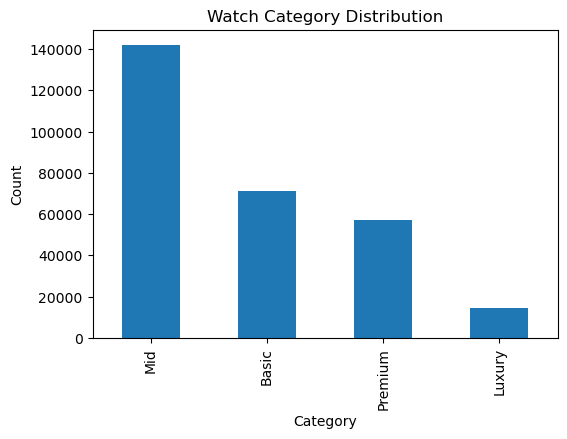

In [16]:
plt.figure(figsize=(6,4))
df["watch_category"].value_counts().plot(kind="bar")
plt.title("Watch Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

**The watch prices were divided into four categories (Basic, Mid, Premium, and Luxury) based on the dataset's price distribution to create meaningful classes for classification.**

In [17]:
x= df.drop(["price", "watch_category"], axis=1)
y= df["watch_category"]

In [18]:
print(x)

                  brand                           model     yop       cond  \
0       Audemars Piguet  Royal Oak Offshore Chronograph  2019.0     Unworn   
1       Audemars Piguet           Royal Oak Selfwinding  2012.0  Very good   
2       Audemars Piguet           Royal Oak Chronograph  2020.0     Unworn   
3       Audemars Piguet           Royal Oak Chronograph  2022.0        New   
4       Audemars Piguet  Royal Oak Offshore Chronograph  2020.0  Very good   
...                 ...                             ...     ...        ...   
284486           Zenith                 Defy El Primero  2022.0  Very good   
284487           Zenith              Chronomaster Sport  2021.0  Very good   
284488           Zenith                      El Primero  2019.0  Very good   
284489           Zenith              Chronomaster Sport  2021.0     Unworn   
284490           Zenith         El Primero Chronomaster  2019.0  Very good   

                       sex  size  
0       Men's watch/Unisex  

In [18]:
print(x.head())
print(72*'-')
print(y.head())

             brand                           model     yop       cond  \
0  Audemars Piguet  Royal Oak Offshore Chronograph  2019.0     Unworn   
1  Audemars Piguet           Royal Oak Selfwinding  2012.0  Very good   
2  Audemars Piguet           Royal Oak Chronograph  2020.0     Unworn   
3  Audemars Piguet           Royal Oak Chronograph  2022.0        New   
4  Audemars Piguet  Royal Oak Offshore Chronograph  2020.0  Very good   

                  sex  size  
0  Men's watch/Unisex  42.0  
1  Men's watch/Unisex  39.0  
2             Unknown  41.0  
3  Men's watch/Unisex  38.0  
4  Men's watch/Unisex  40.0  
------------------------------------------------------------------------
0    Premium
1     Luxury
2     Luxury
3     Luxury
4    Premium
Name: watch_category, dtype: object


In [19]:
categorical_cols = x.select_dtypes(include="object").columns
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    x[col] = le.fit_transform(x[col])
    encoders[col] = le

In [20]:
x.dtypes

brand      int64
model      int64
yop      float64
cond       int64
sex        int64
size     float64
dtype: object

In [22]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42,stratify=y)

In [25]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(random_state=42,max_iter=1000)
lr.fit(x_train,y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [26]:
y_pred=lr.predict(x_test)

In [27]:
y_pred

array(['Mid', 'Mid', 'Mid', ..., 'Mid', 'Mid', 'Mid'], dtype=object)

In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)

Accuracy : 0.5224258330599428
Precision : 0.4051139207271549
Recall : 0.5224258330599428
F1 Score : 0.41109397991973945


**Logistic Regression was used as the baseline classification model to predict watch categories.**

In [30]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(criterion='entropy',max_depth=3,max_features=3,random_state=42)
dt.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, max_features=3,
                       random_state=42)

In [31]:
dty_pred=dt.predict(x_test)

In [32]:
dty_pred

array(['Premium', 'Premium', 'Mid', ..., 'Mid', 'Mid', 'Mid'],
      dtype=object)

In [33]:
accuracy = accuracy_score(y_test, dty_pred)
precision = precision_score(y_test, dty_pred, average="weighted")
recall = recall_score(y_test, dty_pred, average="weighted")
f1 = f1_score(y_test, dty_pred, average="weighted")

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)

Accuracy : 0.5816656512161972
Precision : 0.5748155320914445
Recall : 0.5816656512161972
F1 Score : 0.5128610515342916


**Decision Tree Classifier improved the classification performance compared to Logistic Regression but showed lower overall accuracy than ensemble methods.**

In [35]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(random_state=42)
rf.fit(x_train,y_train)

RandomForestClassifier(random_state=42)

In [36]:
rfy_pred=rf.predict(x_test)
rfy_pred

array(['Mid', 'Mid', 'Premium', ..., 'Mid', 'Premium', 'Mid'],
      dtype=object)

In [37]:
accuracy = accuracy_score(y_test, rfy_pred)
precision = precision_score(y_test, rfy_pred, average="weighted")
recall = recall_score(y_test, rfy_pred, average="weighted")
f1 = f1_score(y_test, rfy_pred, average="weighted")

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)

Accuracy : 0.7914655293621409
Precision : 0.7896890495458384
Recall : 0.7914655293621409
F1 Score : 0.7900650464793321


**Random Forest Classifier achieved the highest accuracy, precision, recall, and F1-score, making it the best-performing model for watch category classification.**

In [39]:
from sklearn.ensemble import GradientBoostingClassifier
gb=GradientBoostingClassifier(random_state=42)
gb.fit(x_train,y_train)

GradientBoostingClassifier(random_state=42)

In [41]:
gby_pred=gb.predict(x_test)
gby_pred

array(['Luxury', 'Premium', 'Premium', ..., 'Mid', 'Premium', 'Mid'],
      dtype=object)

In [42]:
accuracy = accuracy_score(y_test, gby_pred)
precision = precision_score(y_test, gby_pred, average="weighted")
recall = recall_score(y_test, gby_pred, average="weighted")
f1 = f1_score(y_test, gby_pred, average="weighted")

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)

Accuracy : 0.7564559216384684
Precision : 0.753383665921572
Recall : 0.7564559216384684
F1 Score : 0.7524988271867463


**Gradient Boosting Classifier produced good classification performance but was slightly less accurate than the Random Forest Classifier.**

In [44]:
from sklearn.metrics import classification_report
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

       Basic       0.21      0.59      0.31      7740
      Luxury       0.00      0.00      0.00         0
         Mid       0.94      0.52      0.67     77602
     Premium       0.00      0.00      0.00         6

    accuracy                           0.52     85348
   macro avg       0.29      0.28      0.24     85348
weighted avg       0.87      0.52      0.63     85348



In [46]:
print(classification_report(dty_pred,y_test))

              precision    recall  f1-score   support

       Basic       0.37      0.80      0.50      9784
      Luxury       0.00      0.00      0.00         0
         Mid       0.93      0.56      0.70     71318
     Premium       0.12      0.48      0.19      4246

    accuracy                           0.58     85348
   macro avg       0.35      0.46      0.35     85348
weighted avg       0.83      0.58      0.65     85348



In [47]:
print(classification_report(rfy_pred,y_test))

              precision    recall  f1-score   support

       Basic       0.87      0.84      0.85     22208
      Luxury       0.55      0.70      0.62      3383
         Mid       0.82      0.81      0.82     42947
     Premium       0.69      0.70      0.69     16810

    accuracy                           0.79     85348
   macro avg       0.73      0.76      0.74     85348
weighted avg       0.80      0.79      0.79     85348



In [48]:
print(classification_report(gby_pred,y_test))

              precision    recall  f1-score   support

       Basic       0.81      0.83      0.82     20935
      Luxury       0.54      0.67      0.60      3418
         Mid       0.83      0.75      0.79     46909
     Premium       0.56      0.68      0.61     14086

    accuracy                           0.76     85348
   macro avg       0.68      0.73      0.71     85348
weighted avg       0.77      0.76      0.76     85348



In [49]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [50]:
grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(x_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy')

In [51]:
print("Best Parameters:")
print(grid.best_params_)
best_rf = grid.best_estimator_

gy_pred = best_rf.predict(x_test)

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


In [52]:
accuracy = accuracy_score(y_test, gy_pred)
precision = precision_score(y_test, gy_pred, average="weighted")
recall = recall_score(y_test, gy_pred, average="weighted")
f1 = f1_score(y_test, gy_pred, average="weighted")

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)

Accuracy : 0.7990111074659043
Precision : 0.7965166925895699
Recall : 0.7990111074659043
F1 Score : 0.7969015970663608


In [58]:
print(classification_report(y_test, gy_pred))

              precision    recall  f1-score   support

       Basic       0.84      0.88      0.86     21359
      Luxury       0.72      0.55      0.63      4268
         Mid       0.81      0.84      0.82     42653
     Premium       0.72      0.67      0.69     17068

    accuracy                           0.80     85348
   macro avg       0.77      0.73      0.75     85348
weighted avg       0.80      0.80      0.80     85348



In [53]:
print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


In [55]:
feature_importance = pd.DataFrame({ "Feature": x.columns, "Importance": best_rf.feature_importances_})
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)
print(feature_importance)

  Feature  Importance
0   brand    0.339930
1   model    0.287442
5    size    0.145722
2     yop    0.104527
3    cond    0.092413
4     sex    0.029967


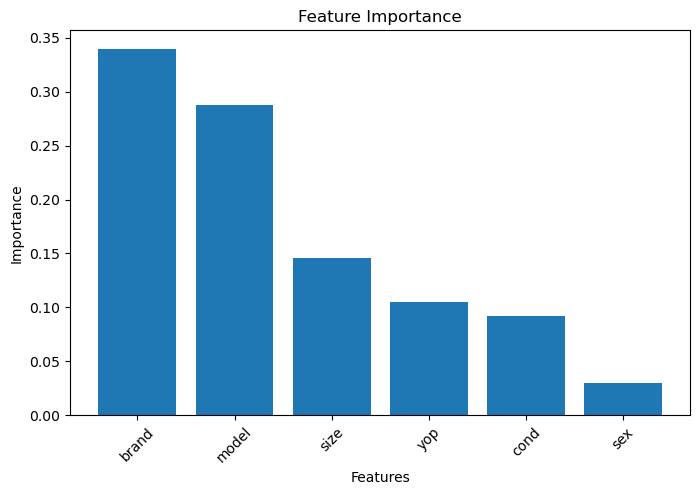

In [56]:
plt.figure(figsize=(8,5))
plt.bar(feature_importance["Feature"],feature_importance["Importance"])
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

**The model assigned higher importance to a few key features, indicating that they contributed more significantly to predicting the watch category.**

In [59]:
import joblib
joblib.dump(best_rf, "watch_category_classifier.pkl")

['watch_category_classifier.pkl']

In [60]:
joblib.dump(encoders, "classification_label_encoders.pkl")

['classification_label_encoders.pkl']

In [61]:
import os

print(os.getcwd())

C:\Users\vidit\OWN PROJECTS(SEM-V)
